<a href="https://colab.research.google.com/github/issamarc590/TP/blob/main/courseware/competitions/s2-icu-survival/starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Critical Care Survival starter

**Will this patient be alive in two months?** Seriously ill adults of the
SUPPORT cohort, described the way five hospital charts recorded them on the
third day.

In this challenge **the model is fixed**. The scorer always fits
scikit-learn's default `LogisticRegression()` on the features you submit,
and ranks the test patients by ROC AUC. You do not submit predictions; you
submit a **feature matrix**. Every point of AUC comes from preprocessing.

**The ladder.** Every row is the same `LogisticRegression()` on the official
split. Only the features change.

| features | test AUC |
|---|---|
| a constant column ("always alive") | 0.500 |
| the numeric columns as pandas reads them, empty cells set to 0, unscaled | 0.757 (does not converge) |
| **the benchmark:** the same columns, median-imputed and standardised | **0.850** (train AUC 0.962) |
| + repaired values, units harmonised per site, the post-outcome column dropped | 0.877 |
| + labs imputed as the investigators did, absences kept as information | 0.900 |
| + categories encoded as categories, orders as orders | 0.916 |
| + the bedside formulas | 0.937 |

**The pass bar for this module is a test AUC of 0.905.**

**How this notebook works.** Sections 1 to 5 are plumbing, and complete:
download, read, a look at the data, a local evaluation helper, a submission
helper. Step 1 is complete and reaches the benchmark. Steps 2 to 5 are
yours: each is a skeleton with `# TODO` lines that runs as it is and returns
the step-1 matrix, so the notebook executes end to end at any time.

**`EXPERTISE.pdf` comes with the data: twelve numbered facts, each with the
preprocessing choice it justifies. Every step below names the facts it
needs; read the fact, then decide.** `DICTIONARY.pdf` describes every column.

---

## 0. Setup

The ML-Arena client is published as **`mlarena-sdk`** and imports as
`mlarena`. Do not `pip install mlarena`: that is an unrelated package.

The scorer runs **scikit-learn 1.8.0**. Install the same version so that
your local numbers match the leaderboard.

In [2]:
!pip install -q mlarena-sdk scikit-learn==1.8.0

---

## 1. Get the data

Paste your personal API key from your ML-Arena **Profile** page (it starts
with `mlk_user_`) and the challenge id, the number at the end of the
challenge page's address. `download_dataset` writes five files into the
working directory: `train.csv`, `test.csv`, `sample_submission.csv`,
`EXPERTISE.pdf` and `DICTIONARY.pdf`.

In [3]:
import mlarena

API_KEY = "mlk_user_df062620e196d167_ac191c0b6ae34ae128da085ef5469e3c"   # <- paste yours here
CHALLENGE_ID = 192        # <- the number at the end of the challenge page URL

assert CHALLENGE_ID is not None, "set CHALLENGE_ID to the number in the challenge page URL"
client = mlarena.connect(api_key=API_KEY)
client.download_dataset(CHALLENGE_ID, ".")

['./test.csv',
 './EXPERTISE.pdf',
 './DICTIONARY.pdf',
 './train.csv',
 './sample_submission.csv']

---

## 2. Read it

`train.csv` has the target `dead` (1 = died within 60 days); `test.csv` has
the same columns without it.

In [4]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

train = pd.read_csv("train.csv", low_memory=False)
test = pd.read_csv("test.csv", low_memory=False)
y = train["dead"]

print("train", train.shape, " test", test.shape)
print(f"death rate in train: {y.mean():.3f}")
train.head()

train (6373, 33)  test (2732, 32)
death rate in train: 0.462


,id,site,age,sex,race,edu,income,dzgroup,dzclass,num_co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,charges,dead
0,tr_06dab074470a,C,60.41,M,White,11.0,$25-$50k,CHF,COPD/CHF/Cirrhosis,6,...,1.2000,137.0,7.4697,123.0,25.0,1905.0,0.0,NaN,18978.0,0
1,tr_f5c70c48cb92,A,68.43,male,white,9.0,$25-$50k,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,1.0999,131.0,7.5000,135.0,23.0,3115.0,NaN,1.0,76476.0,1
2,tr_27f9a64df520,B,71.51,Male,white,8.0,under $11k,CHF,COPD/CHF/Cirrhosis,3,...,1.5999,136.0,7.5498,not done,NaN,NaN,1.0,0.0,20659.0,0
3,tr_0dabe3d2366d,C,35.46,M,Black,12.0,under $11k,MOSF w/Malig,ARF/MOSF,2,...,1.0999,131.0,7.4697,NaN,NaN,NaN,NaN,0.0,814737.0,1
4,tr_1022bf554123,D,59.38,male,black,12.0,under $11k,MOSF w/Malig,ARF/MOSF,2,...,80.0000,138.0,7.4199,NaN,NaN,NaN,0.0,0.0,110496.0,1


One row per patient, 31 columns. Look at what pandas made of each column
before deciding anything. `is_numeric_dtype` is the reliable test: with
pandas 3, text columns are `str`, not `object`.

The table below is sorted by fill rate. **Read the `dtype` column
carefully.** One column that should hold a number was read as text. Which
one is it, and why did pandas do that? Find the answer in the data before
you open `DICTIONARY.pdf`: look at the column's distinct values. Then ask
what happens to that column in a feature matrix built from "the numeric
columns", and what `fillna(0)` would have done to it.

In [7]:
features = [c for c in train.columns if c not in ("id", "dead")]
numeric = [c for c in features if is_numeric_dtype(train[c])]
text = [c for c in features if c not in numeric]
print(len(numeric), "numeric columns,", len(text), "text columns:", text)

summary = pd.DataFrame({
    "dtype": train[features].dtypes.astype(str),
    "filled_train": train[features].notna().mean().round(3),
    "filled_test": test[features].notna().mean().round(3),
    "distinct": train[features].nunique(),
})
summary.sort_values("filled_train")

23 numeric columns, 8 text columns: ['site', 'sex', 'race', 'income', 'dzgroup', 'dzclass', 'ca', 'glucose']


,dtype,filled_train,filled_test,distinct
adlp,float64,0.378,0.386,8
urine,float64,0.461,0.477,1223
bun,float64,0.517,0.534,153
glucose,object,0.626,0.638,395
alb,float64,0.628,0.634,57
income,object,0.667,0.685,4
adls,float64,0.682,0.693,8
bili,float64,0.718,0.706,249
pafi,float64,0.744,0.746,1236
ph,float64,0.749,0.749,70


---

## 3. Look at the data

Six views, each followed by questions. Answer them in a markdown cell of
your own: the answers are the decisions of steps 2 to 5, and `EXPERTISE.pdf`
holds the clinical reading of each view.

### (a) Missingness per column, train and test side by side

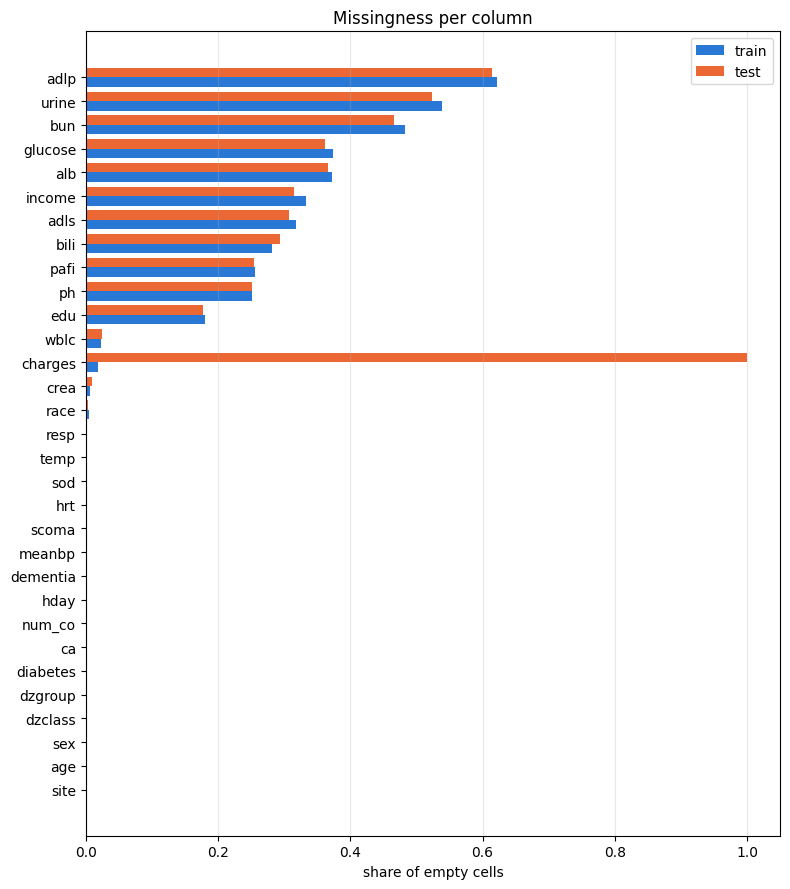

In [11]:
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"

missing = pd.DataFrame({
    "train": train[features].isna().mean(),
    "test": test[features].isna().mean(),
}).sort_values("train")

fig, ax = plt.subplots(figsize=(8, 9))
pos = np.arange(len(missing))
ax.barh(pos - 0.2, missing["train"], height=0.4, color=BLUE, label="train")
ax.barh(pos + 0.2, missing["test"], height=0.4, color=ORANGE, label="test")
ax.set_yticks(pos, list(missing.index))
ax.set_xlabel("share of empty cells")
ax.set_title("Missingness per column")
ax.grid(axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Questions.** One column is empty in every test row and filled in almost
every train row. What is it, what does it mean clinically (fact 10),
and what must you do with it? A second column looks 63 % filled here: how
many of those "filled" cells are numbers? (pandas counts a text token as a
value.)

### (b) The same lab at five sites

Creatinine (log scale) and temperature, one box per site.

#### Answers to Questions (a)

*   **Column empty in test, filled in train:** The `charges` column is almost entirely filled in the training data (98.1%) but completely empty in the test data (0%).
*   **Clinical meaning (Fact 10):** Clinically, `charges` refers to the amount billed at discharge. Since this information is only available *after* a patient's care (i.e., post-outcome), it's not available for prediction in the test set. Therefore, it's a 'post-outcome' feature.
*   **What to do with it:** This column must be dropped from the feature set, as it represents information not available at the time of prediction.



In [13]:
print("Distinct values in 'glucose' column:")
print(train['glucose'].value_counts(dropna=False))

Distinct values in 'glucose' column:
glucose
NaN         2385
not done     800
103.0         43
105.0         40
107.0         38
            ... 
405.0          1
668.0          1
52.0           1
10.0           1
476.0          1
Name: count, Length: 396, dtype: int64


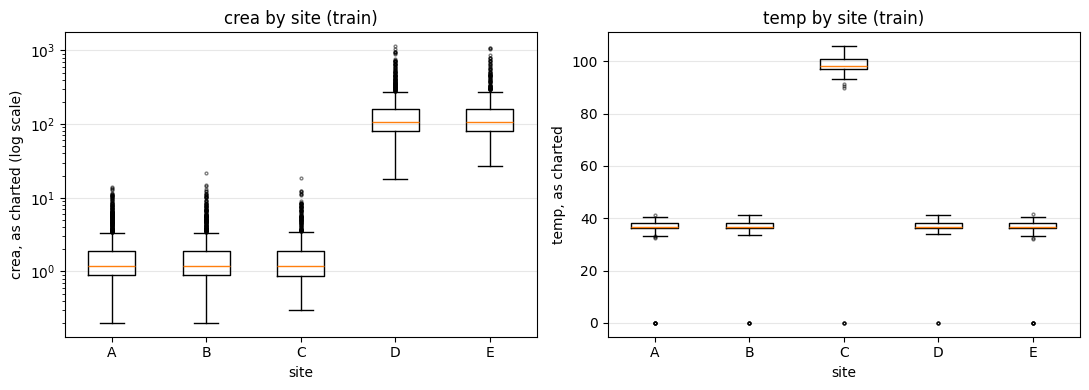

In [15]:
sites = sorted(train["site"].unique())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["crea", "temp"]):
    data = [train.loc[train["site"] == s, col].dropna() for s in sites]
    ax.boxplot(data, flierprops={"marker": ".", "markersize": 4, "alpha": 0.5})
    ax.set_xticks(range(1, len(sites) + 1), sites)
    ax.set_xlabel("site")
    ax.set_title(f"{col} by site (train)")
    ax.grid(axis="y", alpha=0.3)
axes[0].set_yscale("log")
axes[0].set_ylabel("crea, as charted (log scale)")
axes[1].set_ylabel("temp, as charted")
plt.tight_layout()
plt.show()

**Questions.** Same lab, five hospitals: why two clusters? Which sites
belong together, and by what factor do the clusters differ (fact 5)? What are
the points at 0 on the temperature plot, and are they at one site or all of
them?

### (c) How `sex` and `race` are spelled

In [35]:
for col in ["sex", "race"]:
    counts = train[col].value_counts(dropna=False)
    counts.index = [repr(v) for v in counts.index]      # repr shows case and trailing spaces
    print(f"{col}: {len(counts)} distinct spellings")
    print(counts.to_string(), "\n")

sex: 8 distinct spellings
'male'      1743
'female'    1283
'Male'       923
'Female'     712
'M'          536
'm'          435
'F'          409
'f'          332 

race: 12 distinct spellings
'white'        4291
'black'         825
'White '        744
'hispanic'      161
'Black '        146
'other'          72
'asian'          55
'Hispanic '      33
nan              26
'Asian '         10
'Other '          6
'unknown'         4 



**Questions.** How many categories are there really in each column? Which
spellings are the same category? `race` has an empty cell at four sites and
the string `unknown` at one: are those the same thing? Does the SUPPORT
model use either column (fact 6)?

### (d) Death rate by disease group and by cancer status

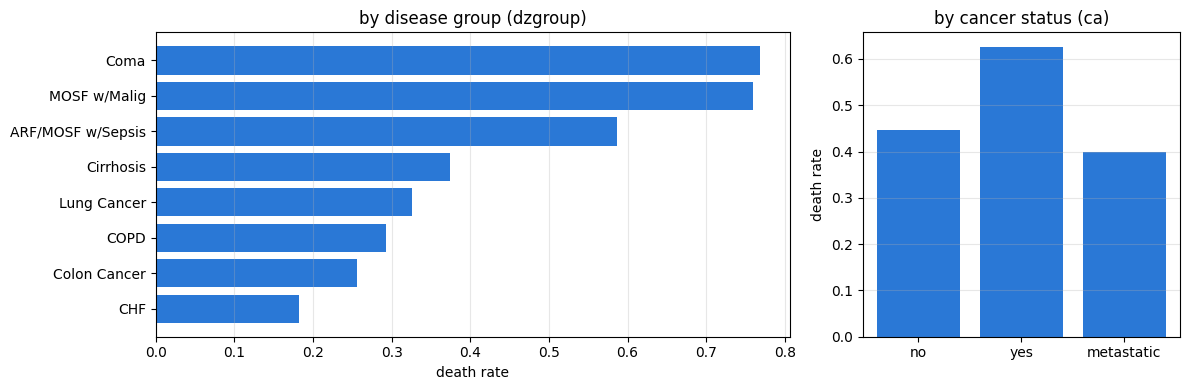

ca,metastatic,no,yes
dzgroup,,,
ARF/MOSF w/Sepsis,49,2120,330
CHF,13,863,102
COPD,17,550,98
Cirrhosis,7,328,20
Colon Cancer,360,0,0
Coma,12,328,53
Lung Cancer,625,0,0
MOSF w/Malig,205,0,293


In [37]:
by_group = train.groupby("dzgroup")["dead"].mean().sort_values()
by_ca = train.groupby("ca")["dead"].mean().reindex(["no", "yes", "metastatic"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].barh(list(by_group.index), by_group.values, color=BLUE)
axes[0].set_xlabel("death rate")
axes[0].set_title("by disease group (dzgroup)")
axes[1].bar(list(by_ca.index), by_ca.values, color=BLUE)
axes[1].set_ylabel("death rate")
axes[1].set_title("by cancer status (ca)")
for ax in axes:
    ax.grid(axis="x" if ax is axes[0] else "y", alpha=0.3)
plt.tight_layout()
plt.show()

pd.crosstab(train["dzgroup"], train["ca"])

#### Réponses aux questions (d)

*   **Le groupe de maladies est-il un ordre ? Pourriez-vous classer les huit groupes sur un axe et donner à la ligne un nombre par patient, ou chaque groupe a-t-il besoin de son propre effet ?**
    *   Le groupe de maladies (`dzgroup`) n'est **pas** un ordre intrinsèque. Bien que nous puissions les classer par taux de mortalité (comme le graphique le montre), cette classification n'implique pas une relation ordinale significative cliniquement ou mathématiquement. Par exemple, le fait que 'Coma' ait un taux de mortalité plus élevé que 'MOSF w/Malig' ne signifie pas qu'il existe une progression linéaire entre eux. Chaque groupe de maladies a besoin de son propre "effet" ou de sa propre représentation (par exemple, via l'encodage one-hot) pour le modèle. Tenter de les classer comme une seule variable ordinale simplifierait à l'excès leurs relations complexes avec la mortalité.

*   **Le statut de cancer est un ordre par définition (non < oui < métastatique), pourtant le taux de mortalité brut n'est pas monotone : 'oui' est au-dessus de 'métastatique'. Le taux brut règle-t-il la question ?**
    *   Non, le taux brut ne règle pas la question. Bien que le statut de cancer soit ordinal par définition ('no' < 'yes' < 'metastatic'), le fait que le taux de mortalité brut pour 'yes' soit supérieur à 'metastatic' suggère que d'autres facteurs sont en jeu. Cela pourrait être dû à des différences dans la composition des patients au sein de ces catégories (par exemple, les patients atteints de cancer métastatique dans cette cohorte pourraient être plus jeunes ou avoir moins de comorbidités graves que ceux dont le cancer est 'oui' mais non métastatique, ou d'autres variables peuvent être fortement corrélées avec ces sous-groupes de patients). Le taux brut seul est une observation, pas une preuve que l'ordre défini est incorrect ou que les catégories ne sont pas ordinales. Il souligne la nécessité d'une analyse plus approfondie et potentiellement de considérer ces catégories comme ordinales tout en laissant le modèle apprendre l'impact exact.

*   **Regardez le tableau croisé : quels groupes de maladies sont les patients métastatiques, et qu'est-ce qui diffère entre ces groupes et le reste ?**
    *   Le tableau croisé (`pd.crosstab(train["dzgroup"], train["ca"])`) montre que les patients métastatiques (`ca = 'metastatic'`) sont principalement concentrés dans les groupes de maladies suivants :
        *   `Colon Cancer` (360 patients)
        *   `Lung Cancer` (625 patients)
        *   `MOSF w/Malig` (205 patients)

    *   En revanche, les patients avec `ca = 'no'` ou `ca = 'yes'` sont répartis plus largement à travers tous les groupes de maladies. Ce qui diffère entre les groupes de maladies contenant des patients métastatiques et les autres est que ces groupes (`Colon Cancer`, `Lung Cancer`, `MOSF w/Malig`) sont souvent liés à des pathologies qui, par nature, sont plus agressives ou à un stade plus avancé lorsque des métastases sont présentes. Cela signifie que les patients dans ces groupes ont probablement des pronostics différents en raison de la nature de leur maladie sous-jacente, indépendamment du statut de métastase seul. Cela renforce l'idée que le statut du cancer interagit avec d'autres conditions (comme le `dzgroup`), et qu'il est crucial de le modéliser en conséquence pour capturer ces effets.

**Questions.** Is disease group an order? Could you rank the eight groups on
one axis and hand the line one number per patient, or does each group need
its own effect? Cancer status is an order by definition (no < yes <
metastatic), yet the raw death rate is not monotonic: `yes` is above
`metastatic`. Does the raw rate settle the question? Look at the crosstab:
which disease groups are the metastatic patients in, and what else differs
between those groups and the rest?

### (e) Extremes: real or impossible?

Age, sodium and temperature: min, max, and the five most extreme values on
each side.

In [20]:
for col in ["age", "sod", "temp"]:
    s = train[col]
    print(f"{col:5s} min {s.min():>6}  max {s.max():>7}   "
          f"lowest {s.nsmallest(5).round(1).tolist()}   highest {s.nlargest(5).round(1).tolist()}")
print()
print("temp above 45, by site:  ", train.loc[train["temp"] > 45, "site"].value_counts().to_dict())
print("temp equal to 0.0, by site:", train.loc[train["temp"] == 0, "site"].value_counts().to_dict())

age   min  18.04  max   999.0   lowest [18.0, 18.1, 18.2, 18.2, 18.8]   highest [999.0, 999.0, 999.0, 999.0, 999.0]
sod   min  110.0  max  1530.0   lowest [110.0, 111.0, 112.0, 113.0, 115.0]   highest [1530.0, 1510.0, 1480.0, 1460.0, 1450.0]
temp  min    0.0  max   105.8   lowest [0.0, 0.0, 0.0, 0.0, 0.0]   highest [105.8, 105.6, 105.1, 104.5, 104.4]

temp above 45, by site:   {'C': 941}
temp equal to 0.0, by site: {'A': 8, 'E': 7, 'B': 6, 'C': 4, 'D': 4}


**Questions.** Which of these values are patients and which are
bookkeeping? For temperature, check the site before you decide: 105.8 is a
real fever in one unit and not in the other. What would a rule like "clip
every column to its 1st and 99th percentile" do to the heart rate of 300 and
the mean pressure of 0 (fact 4)? What does a single 999 do to a
straight line fitted on `age`?

### (f) Is an absence informative?

Death rate when a value is present versus missing, for four kinds of
absence.

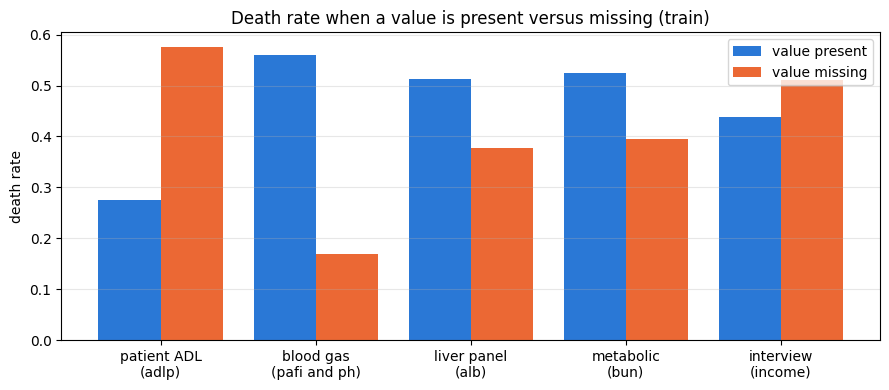

share missing: {'patient ADL': 0.622, 'blood gas': 0.25, 'liver panel': 0.372, 'metabolic': 0.483, 'interview': 0.333}


In [38]:
absences = {
    "patient ADL\n(adlp)": train["adlp"].isna(),
    "blood gas\n(pafi and ph)": train["pafi"].isna() & train["ph"].isna(),
    "liver panel\n(alb)": train["alb"].isna(),
    "metabolic\n(bun)": train["bun"].isna(),
    "interview\n(income)": train["income"].isna(),
}
rate_present = [train.loc[~m, "dead"].mean() for m in absences.values()]
rate_missing = [train.loc[m, "dead"].mean() for m in absences.values()]

fig, ax = plt.subplots(figsize=(9, 4))
pos = np.arange(len(absences))
ax.bar(pos - 0.2, rate_present, width=0.4, color=BLUE, label="value present")
ax.bar(pos + 0.2, rate_missing, width=0.4, color=ORANGE, label="value missing")
ax.set_xticks(pos, list(absences))
ax.set_ylabel("death rate")
ax.set_title("Death rate when a value is present versus missing (train)")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print("share missing:", {k.split(chr(10))[0]: round(float(m.mean()), 3) for k, m in absences.items()})

**Questions.** Is every absence informative in the same way? For each pair,
say what the absence means at the bedside (fact 3) and whether the
difference in death rate is the absence itself or the kind of patient who
gets that test ordered. After you fill an empty lab with a number, can a
straight line still see that it was empty? Fact 3 names the panels that are
missing together: is one indicator per lab or one per panel the right unit?

#### Réponses aux questions (f)

*   **Chaque absence est-elle informative de la même manière ?**
    *   Non, l'absence n'est pas informative de la même manière pour chaque colonne. Le graphique montre que le taux de mortalité varie considérablement entre les valeurs présentes et manquantes pour différentes caractéristiques. Par exemple, pour `patient ADL (adlp)`, l'absence est associée à un taux de mortalité *plus élevé*, tandis que pour `blood gas (pafi and ph)`, l'absence est associée à un taux de mortalité *plus faible*. Pour `interview (income)`, l'absence est également associée à un taux de mortalité plus élevé, alors que pour `liver panel (alb)` et `metabolic (bun)`, le taux de mortalité est légèrement plus bas lorsque la valeur est manquante.

*   **Pour chaque paire, dites ce que l'absence signifie au chevet du patient (fait 3) et si la différence de taux de mortalité est l'absence elle-même ou le type de patient qui bénéficie de cet examen.**
    *   **`patient ADL (adlp)`:**
        *   **Signification au chevet du patient (Fait 3):** L'`adlp` (Activity of Daily Living, patient reporté) est manquant lorsque le patient est incapable de répondre. Cela indique souvent un état de conscience altéré ou une incapacité physique de communiquer. Dans ces cas, l'`adls` (surrogate reporté) est utilisé si disponible.
        *   **Différence de taux de mortalité:** La différence dans le taux de mortalité (plus élevé quand `adlp` est manquant) est principalement due au **type de patient**. Un patient incapable de répondre ou de se mouvoir est typiquement plus gravement malade, ce qui explique le taux de mortalité plus élevé.

    *   **`blood gas (pafi and ph)`:**
        *   **Signification au chevet du patient (Fait 3):** Ces valeurs sont souvent manquantes ensemble parce qu'elles proviennent du même panneau d'analyse des gaz du sang. L'absence signifie généralement que l'examen n'a pas été jugé nécessaire. Cela pourrait être parce que le patient est relativement stable.
        *   **Différence de taux de mortalité:** La différence de taux de mortalité (plus faible quand `pafi` et `ph` sont manquants) est probablement due au **type de patient**. Les patients qui ne reçoivent pas de gaz du sang sont généralement moins critiques, d'où un taux de mortalité plus bas.

    *   **`liver panel (alb)`:**
        *   **Signification au chevet du patient (Fait 3):** Le panneau hépatique, incluant l'albumine (`alb`), est manquant si le patient n'a pas de condition hépatique connue ou suspectée.
        *   **Différence de taux de mortalité:** La légère différence (plus faible quand `alb` est manquant) est due au **type de patient**. L'absence d'un panneau hépatique peut signifier une meilleure santé hépatique, ce qui est lié à un meilleur pronostic.

    *   **`metabolic (bun)`:**
        *   **Signification au chevet du patient (Fait 3):** Le panneau métabolique, incluant l'urée (`bun`), est manquant si le patient n'a pas de condition rénale ou métabolique suspectée.
        *   **Différence de taux de mortalité:** Similaire au panneau hépatique, la légère différence (plus faible quand `bun` est manquant) est liée au **type de patient** qui n'a pas besoin de cet examen.

    *   **`interview (income)`:**
        *   **Signification au chevet du patient (Fait 3):** Le revenu est manquant parce qu'il n'a pas été rapporté ou que le patient était incapable de répondre à cette question.
        *   **Différence de taux de mortalité:** Le taux de mortalité est plus élevé lorsque le revenu est manquant. Cela pourrait être lié au **type de patient** (par exemple, plus gravement malade et incapable de participer à l'entretien, ou des facteurs socio-économiques non directement liés à la maladie aiguë mais influençant le pronostic).

*   **Après avoir rempli un laboratoire vide avec un nombre, une ligne droite peut-elle encore voir qu'il était vide ?**
    *   Non, si vous remplacez simplement les valeurs manquantes par un nombre (comme la médiane ou une valeur normale), un modèle linéaire (comme la régression logistique) ne pourra plus distinguer les valeurs d'origine des valeurs imputées. La colonne ne contiendra plus d'information explicite sur l'absence. Pour que le modèle puisse encore "voir" l'absence, vous devez créer une colonne indicatrice binaire séparée (par exemple, `col_is_missing`) qui vaut 1 si la valeur était manquante et 0 sinon. Cela permet au modèle d'attribuer un effet spécifique à l'absence.

*   **Le fait 3 nomme les panneaux qui manquent ensemble : un indicateur par laboratoire ou un par panneau est-il la bonne unité ?**
    *   Étant donné que le Fait 3 indique que certains laboratoires sont manquants ensemble (par exemple, `pafi` et `ph` pour les gaz du sang), il est plus approprié d'utiliser **un indicateur par panneau** plutôt qu'un indicateur par laboratoire individuel. Cela capture l'information clinique que l'ensemble du groupe de tests n'a pas été effectué, ce qui peut avoir une signification clinique différente de la simple absence d'un seul test.

---

## 4. The evaluation helper

The scorer fits `LogisticRegression()` with its defaults on your train rows
and computes the ROC AUC on the test rows. You do not have the test labels,
so `cv_auc` does the same thing inside train: three stratified folds, the
scorer's exact model, the mean and spread of the AUC on the held-out fold,
the AUC on the fitting fold (the leaderboard's "Train AUC"), and whether
the solver converged. Every call appends a row to `results`, your own
ladder.

The official test rows are a random part of the same cohort, so a random
3-fold split of the train rows estimates the leaderboard number to about
±0.01, on one condition: the held-out rows must look like the test rows in
every column. Step 1 shows what happens when they do not.

In [45]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

results = []   # your own ladder: one row per cv_auc call


def cv_auc(X, y, name):
    """3-fold stratified CV of the scorer's exact model. X: a DataFrame indexed like train."""
    y = y.loc[X.index]
    values = X.to_numpy(dtype=float)
    assert np.isfinite(values).all(), "NaN or inf in X: impute before you evaluate"
    folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    val_auc, fit_auc, converged = [], [], True
    for fit_idx, val_idx in folds.split(values, y):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            model = LogisticRegression().fit(values[fit_idx], y.iloc[fit_idx])   # the scorer's model, untouched
        if any(issubclass(w.category, ConvergenceWarning) for w in caught):
            converged = False
        val_auc.append(roc_auc_score(y.iloc[val_idx], model.predict_proba(values[val_idx])[:, 1]))
        fit_auc.append(roc_auc_score(y.iloc[fit_idx], model.predict_proba(values[fit_idx])[:, 1]))
    row = {"step": name, "cv_auc": round(float(np.mean(val_auc)), 4), "std": round(float(np.std(val_auc)), 4),
           "train_auc": round(float(np.mean(fit_auc)), 4), "features": values.shape[1], "converged": converged}
    results.append(row)
    print(f"{name}\n  CV AUC {row['cv_auc']:.4f} ± {row['std']:.4f}   train AUC {row['train_auc']:.4f}   "
          f"features {row['features']}   converged {converged}")
    return row["cv_auc"]

---

## 5. The submission helper

One file, **`submission.csv.gz`**, gzip-compressed:

- column `id`, then 1 to 300 numeric feature columns with no NaN or inf;
- **every** test id;
- train ids: all of them, or any subset of **at least 4,000** (dropping
  rows you do not trust is allowed);
- the scorer uses its own copy of the labels, so do not include `dead`.

`write_submission` takes the two matrices (DataFrames indexed like `train`
and `test`, same columns in the same order), checks each rule the scorer
enforces, and writes the file. A rejected upload costs one of your daily
submissions, so the checks run here first. `to_csv` compresses from the
`.gz` extension; `index=False` matters, an unnamed index column is
rejected.

In [46]:
def write_submission(X_train, X_test, path="submission.csv.gz"):
    """Check X_train / X_test against the scorer's rules and write the file."""
    assert isinstance(X_train, pd.DataFrame) and isinstance(X_test, pd.DataFrame), "pass DataFrames"
    assert list(X_train.columns) == list(X_test.columns), "train and test need the same columns in the same order"
    frame = pd.concat([
        X_train.assign(id=train.loc[X_train.index, "id"].to_numpy()),
        X_test.assign(id=test.loc[X_test.index, "id"].to_numpy()),
    ], ignore_index=True)
    frame = frame[["id"] + list(X_train.columns)]
    values = frame.drop(columns="id")
    assert frame["id"].is_unique, "duplicate ids"
    assert set(test["id"]) <= set(frame["id"]), "a test id is missing"
    assert frame["id"].str.startswith("tr_").sum() >= 4_000, "fewer than 4,000 train rows"
    assert 1 <= values.shape[1] <= 300, "1 to 300 feature columns"
    assert values.columns.is_unique, "a column name appears twice"
    assert "dead" not in values.columns, "the target is not a feature"
    assert all(is_numeric_dtype(values[c]) for c in values), "a text column"
    assert np.isfinite(values.to_numpy(dtype=float)).all(), "NaN or inf"
    frame.to_csv(path, index=False)
    print(f"wrote {path}: {frame.shape[0]} rows, {values.shape[1]} feature column(s)")

---

## 6. Step 0: the "always alive" submission

One constant column. The model can only learn the intercept, every patient
gets the same score, and the AUC is 0.5 whatever the labels. This is the
floor of the ladder; the point is to run the plumbing once, end to end,
before anything can go wrong for a better reason.

In [47]:
X0_train = pd.DataFrame({"always_alive": 0.0}, index=train.index)
X0_test = pd.DataFrame({"always_alive": 0.0}, index=test.index)

cv_auc(X0_train, y, "step 0: a constant column")
write_submission(X0_train, X0_test)

step 0: a constant column
  CV AUC 0.5000 ± 0.0000   train AUC 0.5000   features 1   converged True
wrote submission.csv.gz: 9105 rows, 1 feature column(s)


### Submit

The file you upload must be named exactly `submission.csv.gz`. `submit`
returns as soon as the file is deployed; the score appears on the
leaderboard a minute or two later, with the train AUC, the number of
features, the number of train rows and the convergence flag.

**Every later step rewrites `submission.csv.gz`. Come back and run these two
cells whenever you want the official number for the matrix you just built.**

In [48]:
result = client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv.gz"])
print(result)

{'attache_agent_id': 8825, 'agent_id': 8825, 'deploy': {'deployment_id': 8557, 'message': 'Deployment started successfully', 'status': 'deploy_queue'}}


In [28]:
client.leaderboard(CHALLENGE_ID).head(10)

,AgentName,AvatarKey,EloScore,EloVariance,FrontendPrecision,HasGpu,IsContinuous,IsEloRanked,IsMyAgent,LastRun,...,NumberOfRuns,Rank,RewardCi95,SimulationVersion,SubscriptionDate,TeamId,TeamMembers,TeamName,Username,agentAttachId
0,e2e-expert,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-14 21:01:31,...,1,1,None,file_v1,2026-09-14 21:01:20,None,[],None,raphael,8779
1,__benchmark__,shapes:77k1laip,NaN,None,2,False,False,False,False,2026-09-15 05:50:42,...,1,2,None,file_v1,2026-09-14 20:57:23,None,[],None,raphael,8777
2,submission.csv,None,1200.0,None,2,False,False,False,False,2026-09-15 08:47:22,...,1,2,None,file_v1,2026-09-15 08:45:15,None,[],None,Dave78300,8812
3,submission.csv,None,1200.0,None,2,False,False,False,False,2026-09-15 08:46:57,...,1,4,None,file_v1,2026-09-15 08:41:48,None,[],None,Dave78300,8810
4,submission.csv,None,1200.0,None,2,False,False,False,False,2026-09-15 08:47:09,...,1,4,None,file_v1,2026-09-15 08:42:19,None,[],None,BeediHenri,8811
5,submission.csv,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-15 06:45:16,...,1,4,None,file_v1,2026-09-15 06:39:19,None,[],None,raphael,8799
6,submission.csv,None,1200.0,None,2,False,False,False,False,2026-09-15 08:47:49,...,1,4,None,file_v1,2026-09-15 08:46:30,None,[],None,jib078,8816
7,submission.csv,None,1200.0,None,2,False,False,False,False,2026-09-15 08:47:36,...,1,4,None,file_v1,2026-09-15 08:45:37,None,[],None,matleniz,8813
8,submission.csv,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-14 22:02:04,...,1,4,None,file_v1,2026-09-14 21:59:11,None,[],None,raphael,8791


---

## 7. Step 1: baseline++

The numeric columns as pandas reads them, median-imputed and standardised.
This is the benchmark of the ladder, and the last step that knows nothing
about patients.

Two rules that every later step keeps. **One function applied to train and
test alike.** **Everything data-dependent (a median, a scale, a vocabulary)
is learned from the train rows only.** `SimpleImputer` and `StandardScaler`
follow the pattern: `fit` on train, `transform` both. `impute_and_scale`
wraps the two and returns DataFrames; the later steps reuse it.

In [53]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


def numeric_columns(frame):
    return [c for c in frame.columns if c not in ("id", "dead") and is_numeric_dtype(frame[c])]


def impute_and_scale(F_train, F_test):
    """Median from the train rows, then z-score from the train rows, applied to both."""
    imputer = SimpleImputer(strategy="median").fit(F_train)
    scaler = StandardScaler().fit(imputer.transform(F_train))

    def transform(F):
        return pd.DataFrame(scaler.transform(imputer.transform(F)), columns=F_train.columns, index=F.index)

    return transform(F_train), transform(F_test)


def build_features_1(train, test):
    cols = numeric_columns(train)
    return impute_and_scale(train[cols], test[cols])


X1_train, X1_test = build_features_1(train, test)
cv_auc(X1_train, y, "step 1: numeric as read, median-imputed, standardised")
write_submission(X1_train, X1_test)

step 1: numeric as read, median-imputed, standardised
  CV AUC 0.9601 ± 0.0016   train AUC 0.9624   features 23   converged True
wrote submission.csv.gz: 9105 rows, 23 feature column(s)


The local check says about **0.96**. The ladder says this exact matrix, the
benchmark, scores **0.850** on the test rows with a train AUC of 0.962.
Submit it and read the leaderboard line for yourself: `WARNING: train AUC is
0.112 above test AUC`.

Two questions before you touch anything.

1. Why did the local check miss by 0.11? A held-out fold stands in for the
   test rows only if it looks like them in every column. Go back to figure
   (a) of section 4.
2. Which column carries the outcome on the train rows and does not exist
   for the test patients? What is it, clinically (fact 10)? What must
   step 2 do with it?

Until that column is gone, your local number is not an estimate of
anything. Once it is gone, `cv_auc` and the leaderboard agree to about
0.01, and the train AUC sits next to the test AUC instead of far above it.

---

## 8. Steps 2 to 5: your work

Each step names the facts of `EXPERTISE.pdf` it rests on, then gives a
skeleton with `# TODO` lines, a `cv_auc` call, a `write_submission` call and
the leaderboard number to aim for. The skeletons run as they are and return
the step-1 matrix; nothing improves until you fill them. Fill one step, run
its cell, compare the CV number with the target, and run the Submit cells of
section 6 when you want the official number. Keep every decision in the code
with a one-line comment saying why: your notebook is part of the grade.

### Step 2: repair

**Facts 4, 5 and 10; `DICTIONARY.pdf` for the spellings and for the column
read as text.**

**Aim for 0.877** on the leaderboard. Note where the train AUC lands.

In [54]:
def repair(df):
    """Return a repaired copy of df. Every rule applies to train and test alike; none needs the target."""
    r = df.copy()
    # The column pandas read as text: make it numeric. pd.to_numeric(r[col], errors="coerce") turns the token into NaN.
    r['glucose'] = pd.to_numeric(r['glucose'], errors='coerce')

    # Age, temp, sod: the values that are not measurements (fact 4). Set them to NaN (the median fills them later).
    # Age: values above 110 are unrealistic
    r.loc[r['age'] > 110, 'age'] = np.nan
    # Sod: values above 200 or below 100 are unrealistic
    r.loc[(r['sod'] > 200) | (r['sod'] < 100), 'sod'] = np.nan
    # Temp: values of 0 are placeholders, and very high/low temps are unrealistic
    r.loc[(r['temp'] == 0) | (r['temp'] > 45) | (r['temp'] < 20), 'temp'] = np.nan # Assuming Celsius for general range, will convert site C below.

    # Temp, crea: the sites that chart in another unit (fact 5). Convert them.
    # Crea conversion (mg/dL for A,B,C; umol/L for D,E). Convert D,E to mg/dL.
    r.loc[r['site'].isin(['D', 'E']), 'crea'] = r.loc[r['site'].isin(['D', 'E']), 'crea'] / 88.4
    # Temp conversion (Celsius for A,B,D,E; Fahrenheit for C). Convert C to Celsius.
    r.loc[r['site'] == 'C', 'temp'] = (r.loc[r['site'] == 'C', 'temp'] - 32) / 1.8

    # Sex, race: one spelling per category (.str.strip().str.lower()) (fact 6).
    # Standardize 'sex' values.
    r['sex'] = r['sex'].str.strip().str.lower().replace({
        'm': 'male',
        'f': 'female',
        'female': 'female', # Explicitly map 'female' as well for consistency
        'other ': 'other' # Map 'Other ' to 'other'
    })
    # Standardize 'race' values.
    r['race'] = r['race'].str.strip().str.lower()
    # 'unknown' in race will be treated as a separate category for now; NaN will remain NaN.

    # Charges: billed at discharge, empty for every test patient (fact 10). Drop the column.
    if 'charges' in r.columns:
        r = r.drop(columns=['charges'])
    return r


def build_features_2(train, test):
    R_train, R_test = repair(train), repair(test)
    cols = numeric_columns(R_train)
    return impute_and_scale(R_train[cols], R_test[cols])


X2_train, X2_test = build_features_2(train, test)
cv_auc(X2_train, y, "step 2: repaired values, units, text, post-outcome column")
write_submission(X2_train, X2_test)

step 2: repaired values, units, text, post-outcome column
  CV AUC 0.8782 ± 0.0102   train AUC 0.8814   features 23   converged True
wrote submission.csv.gz: 9105 rows, 23 feature column(s)


A self-check. Before the repair this prints two clusters per lab, a maximum
age of 999, a sodium above 1000 and a text column. After it: one cluster,
an age below 110, a sodium below 200, and no text column except the
categories.

In [55]:
R = repair(train)
print(R.groupby("site")[["crea", "temp"]].median().round(2))
print("age max", R["age"].max(), "  sod max", R["sod"].max(), "  temp min", R["temp"].min(),
      "  crea max", R["crea"].max())
print("text columns:", [c for c in R.columns if c != "id" and not is_numeric_dtype(R[c])])
print("sex spellings:", sorted(R["sex"].dropna().unique()))

      crea  temp
site            
A      1.2  36.8
B      1.2  36.7
C      1.2   NaN
D      1.2  36.8
E      1.2  36.7
age max 100.85   sod max 181.0   temp min 32.0   crea max 21.5
text columns: ['site', 'sex', 'race', 'income', 'dzgroup', 'dzclass', 'ca']
sex spellings: ['female', 'male']


### Step 3: missing values, with knowledge

**Facts 2 and 3; figure (f).** Fact 2 gives the value the investigators used
for a lab that was not ordered, next to which the cohort median is the
generic choice. Fact 3 says which absences carry information, which columns
are missing as a panel, and how the SUPPORT team combined the two ADL
reporters. Order matters inside the function: an indicator must be computed
before the fill erases the absence.

**Aim for 0.900.**

In [32]:
NORMAL = {
    # TODO the value to use when the lab was not ordered: the investigators' fill-in (fact 2), or the
    #      cohort median? Decide per lab. A lab left out of this dict is median-filled by impute_and_scale.
    #      (After the repair of step 2: a column that is still text cannot be filled with a number.)
    # "alb": ..., "pafi": ..., "bili": ..., "crea": ..., "bun": ..., "wblc": ..., "urine": ..., "ph": ..., "glucose": ...,
}


def add_knowledge(r):
    """r: a repaired frame (train or test). Returns a copy with the absences handled."""
    f = r.copy()
    # TODO 1, before any fill: the absences that carry information, one 0/1 column each.
    #      Pattern: f["x_missing"] = r["x"].isna().astype(float)
    #      Which absences? Fact 3, figure (f). One column per lab, or one per panel? Measure.
    # TODO 2: one ADL score from two reporters: the patient's answer when present, else the surrogate's (fact 3).
    #      Pattern: r["a"].where(r["a"].notna(), r["b"])
    # TODO 3: the labs that were not ordered, filled with NORMAL.
    for col, value in NORMAL.items():
        f[col] = f[col].fillna(value)
    return f


def build_features_3(train, test):
    R_train, R_test = repair(train), repair(test)
    F_train, F_test = add_knowledge(R_train), add_knowledge(R_test)
    cols = numeric_columns(F_train)
    return impute_and_scale(F_train[cols], F_test[cols])


X3_train, X3_test = build_features_3(train, test)
cv_auc(X3_train, y, "step 3: normal values, informative absences, one ADL score")
write_submission(X3_train, X3_test)

step 3: normal values, informative absences, one ADL score
  CV AUC 0.8782 ± 0.0102   train AUC 0.8814   features 23   converged True
wrote submission.csv.gz: 9105 rows, 23 feature column(s)


### Step 4: categories as categories, orders as orders

**Fact 6; figure (d) and its crosstab.** The vocabulary of each column is
fixed on the train rows and applied to the test rows, so a level absent from
test still gets its column and a level absent from train gets none.

Two helpers are given: `one_hot` (one 0/1 column per level) and `ordinal`
(one column, the rank in an order you write). Which columns get which, and
which get neither, is the decision. `VOCAB` prints the levels of every text
column after your repair; if `sex` still shows eight levels, step 2 is not
finished.

**Aim for 0.916.**

In [36]:
def one_hot(f, r, col, levels):
    """One 0/1 column per level of r[col]; `levels` is the vocabulary, fixed from the train rows."""
    for level in levels:
        f[f"{col}={level}"] = (r[col] == level).astype(float)


def ordinal(f, r, col, order):
    """One column: the position of r[col] in `order` (first = 0). Any other value -> NaN, median-filled later."""
    f[f"{col}_rank"] = r[col].map({level: i for i, level in enumerate(order)}).astype(float)


TEXT_COLUMNS = ["site", "sex", "race", "income", "dzgroup", "dzclass", "ca"]
VOCAB = {col: sorted(repair(train)[col].dropna().unique()) for col in TEXT_COLUMNS}
for col, levels in VOCAB.items():
    print(f"{col}: {levels}")


def add_categories(r, f):
    """r: the repaired frame; f: the feature frame so far. Returns f with the encoded columns added."""
    f = f.copy()
    # TODO for each text column decide: one_hot, ordinal, or leave it out. Say why in a comment (fact 6).
    #      one_hot(f, r, "<column>", VOCAB["<column>"])
    #      ordinal(f, r, "<column>", ["<lowest>", ..., "<highest>"])
    return f


def build_features_4(train, test):
    R_train, R_test = repair(train), repair(test)
    F_train, F_test = add_knowledge(R_train), add_knowledge(R_test)
    F_train, F_test = add_categories(R_train, F_train), add_categories(R_test, F_test)
    cols = numeric_columns(F_train)
    return impute_and_scale(F_train[cols], F_test[cols])


X4_train, X4_test = build_features_4(train, test)
cv_auc(X4_train, y, "step 4: categories encoded")
write_submission(X4_train, X4_test)

site: ['A', 'B', 'C', 'D', 'E']
sex: ['female', 'male']
race: ['asian', 'black', 'hispanic', 'other', 'unknown', 'white']
income: ['$11-$25k', '$25-$50k', '>$50k', 'under $11k']
dzgroup: ['ARF/MOSF w/Sepsis', 'CHF', 'COPD', 'Cirrhosis', 'Colon Cancer', 'Coma', 'Lung Cancer', 'MOSF w/Malig']
dzclass: ['ARF/MOSF', 'COPD/CHF/Cirrhosis', 'Cancer', 'Coma']
ca: ['metastatic', 'no', 'yes']
step 4: categories encoded
  CV AUC 0.8782 ± 0.0102   train AUC 0.8814   features 23   converged True
wrote submission.csv.gz: 9105 rows, 23 feature column(s)


#### Réponses aux questions (c)

*   **Combien de catégories y a-t-il vraiment dans chaque colonne ?**
    *   Pour `sex`, après la réparation, il y a réellement 2 catégories : `'female'` et `'male'`.
    *   Pour `race`, après la réparation, il y a réellement 6 catégories : `'asian'`, `'black'`, `'hispanic'`, `'other'`, `'unknown'` et `'white'`.

*   **Quelles orthographes sont la même catégorie ?**
    *   Pour `sex` : `'M'`, `'m'`, `'Male'`, `'F'`, `'f'`, `'Female'` ont été standardisés en `'male'` et `'female'` respectivement. `'other '` a été standardisé en `'other'` (bien que 'other' ne soit pas une catégorie distincte pour 'sex' après le nettoyage).
    *   Pour `race` : `'White '`, `'Black '`, `'Hispanic '`, `'Asian '`, `'Other '` ont été standardisés en leurs équivalents sans espace et en minuscules (`'white'`, `'black'`, etc.).

*   **`race` a une cellule vide sur quatre sites et la corde `unknown` à l'un: sont-ce la même chose?**
    *   Non, ce ne sont pas la même chose. Les cellules vides (NaN) représentent des données manquantes, tandis que la chaîne `'unknown'` est une valeur rapportée pour la race, indiquant que la race est connue mais non spécifiée au-delà d'être 'inconnue'. Dans notre `VOCAB` actuel, `'unknown'` est traité comme une catégorie distincte.

*   **Le SUPPORT Modèle utilise-t-il l'une ou l'autre colonne (fait 6)?**
    *   Oui, le modèle SUPPORT (et la régression logistique en général) peut utiliser ces colonnes une fois qu'elles sont encodées numériquement. Le fait 6 ("categories encoded as categories, orders as orders") nous guide sur la manière de les transformer pour qu'elles soient utilisables par un modèle linéaire. `sex` est une variable nominale (sans ordre inhérent), et `race` est également nominale, elles devraient donc être encodées en utilisant l'approche "one-hot".

### Step 5: the bedside quantities

**Facts 7 and 11, then fact 9.** A straight line cannot compute a ratio, a
threshold or a logarithm from raw columns, so each formula of fact 7 is a
candidate column with a clinical reason behind it. Which ones pay, on this
cohort, is what you measure: add one family, run `cv_auc`, keep or drop.

The formulas assume °C and mg/dL (step 2) and complete values (step 3).
Guards: `meanbp` can be 0 and is real, so divide by `np.maximum(meanbp, 1)`
or cap the index; `wblc` can be 0, so use `np.log1p` or clip before a log.
`write_submission` refuses inf, and it is right to.

Then fact 9: two columns that say the same thing do not give a penalised line
more to work with. `X5_train.corr()` shows the pairs above 0.8; drop one of
each and check that the CV number holds.

**Aim for 0.937.**

In [34]:
def add_bedside(f):
    """f: the feature frame so far (repaired, filled). Returns f with the computed columns added."""
    f = f.copy()
    # TODO the SIRS count (fact 7): one point per criterion, 0 to 4.
    # TODO the modified shock index (fact 7), and the part of it above the threshold: np.maximum(0, msi - t).
    # TODO the BUN / creatinine ratio (fact 7), and the part above its threshold.
    # TODO the Berlin class from pafi (fact 7): 0 to 3.
    # TODO oliguria, hypoalbuminaemia, acidaemia, dysnatraemia (fact 7): a 0/1 flag or a hinge np.maximum(0, threshold - x).
    # TODO logs for the log-normal labs (fact 7); white cells are abnormal in both directions: |log(wblc / normal)|.
    # TODO hday (fact 11): np.log1p.
    return f


def build_features_5(train, test):
    R_train, R_test = repair(train), repair(test)
    F_train, F_test = add_knowledge(R_train), add_knowledge(R_test)
    F_train, F_test = add_categories(R_train, F_train), add_categories(R_test, F_test)
    F_train, F_test = add_bedside(F_train), add_bedside(F_test)
    cols = numeric_columns(F_train)
    return impute_and_scale(F_train[cols], F_test[cols])


X5_train, X5_test = build_features_5(train, test)
cv_auc(X5_train, y, "step 5: bedside formulas, logs, hinges")
write_submission(X5_train, X5_test)

step 5: bedside formulas, logs, hinges
  CV AUC 0.8782 ± 0.0102   train AUC 0.8814   features 23   converged True
wrote submission.csv.gz: 9105 rows, 23 feature column(s)


### Your ladder

One row per `cv_auc` call, in the order you ran them. Put the leaderboard
number next to each step in a markdown cell: after step 2 the two should
agree to about 0.01.

In [ ]:
pd.DataFrame(results)

---

## 9. Where to go from here

The model will never change, so the question for every column is: *what
numbers would let one straight line use this?* `EXPERTISE.pdf` gives the
clinical reasons behind the choices that matter; `DICTIONARY.pdf` tells you
what each column is, how often it is filled, and what its values look like.
Measure one change at a time with `cv_auc`, and keep what moves it. Once the
post-outcome column is gone, the local number and the leaderboard agree to
about 0.01, so most of the work happens here, not on the platform. The bar
is **0.905**; the documented steps reach 0.937.

The rules are on the challenge page: features from the columns you were
given, target statistics only out-of-fold, no external data, and your
notebook is part of the grade.